# 11 · State change & ablation

`process(StateChange)` lesions a chosen set of units and `reset()` restores them exactly.
To establish that a lesion is targeted rather than merely large, a **curated** population
consisting of the units with the greatest influence on the output is ablated, and its
effect is compared against a **random same-size lesion**, which serves as the matched
null. A curated lesion is expected to produce a larger effect than a random one.

## A small torch network

In [1]:
import warnings; warnings.filterwarnings('ignore')     # hide the xarray __slots__ FutureWarning
import numpy as np, torch, torch.nn as nn
from brainscore_core.model_interface import (BrainScoreModel, StateChange,
    Selection, Perturbation)
from brainscore.perturbation import build_pytorch_ablation_fn

# A tiny fixed network: 8 numbers in, 64 hidden units, 4 numbers out.
# Small enough that every hidden unit can be lesioned individually.
torch.manual_seed(0)                        # same weights every run
net = nn.Sequential(nn.Linear(8, 64), nn.ReLU(), nn.Linear(64, 4)).eval()
x = torch.randn(5, 8)                       # 5 fixed inputs, reused throughout
baseline = net(x).detach().numpy()          # what the network says BEFORE any damage

# Wrap the network so it can accept a "lesion this" instruction and undo it afterwards.
# Layer '0' is the first Linear -- nn.Sequential names its children by position.
bs = BrainScoreModel(identifier='toy', model=net, region_layer_map={'R': '0'},
                     preprocessors={}, activations_model=None,
                     state_change_fn=build_pytorch_ablation_fn(net))

def effect(units):
    '''Silence some units, measure how much the output moves, then undo it.

    "Ablation" here means forcing those units to output zero. The number returned is
    the average distance between the damaged output and the healthy one -- bigger means
    those units mattered more.
    '''
    bs.process(StateChange(kind='ablation', target=Selection(layer='0', indices=list(units)),
                           perturbation=Perturbation(kind='zero')))
    out = net(x).detach().numpy()           # output with those units silenced
    bs.reset()                              # put the network back before the next test
    return float(np.mean(np.linalg.norm(out - baseline, axis=1)))

## Curate the 4 most influential units

Measure each unit's individual ablation effect, then lesion the top 4 of 64 together.

In [2]:
# Lesion each hidden unit on its own, to see which ones individually matter most.
solo = np.array([effect([j]) for j in range(64)])
curated = np.argsort(solo)[-4:]             # argsort ranks low->high, so [-4:] = top 4
curated_effect = effect(curated)            # now silence all four at once
print(f'curated lesion (top-4 by individual effect): effect = {curated_effect:.3f}')

curated lesion (top-4 by individual effect): effect = 0.269


## Random-lesion null

200 random 4-unit lesions of the same layer. If the curated set is meaningful, its effect
falls above this band.

In [3]:
# Control for lesion size: compare against 200 lesions of 4 RANDOM units.
# This null shows the effect produced when the choice of units carries no information.
null = np.array([effect(np.random.RandomState(s).choice(64, 4, replace=False)) for s in range(200)])
lo, med, hi = np.percentile(null, [5, 50, 95])   # middle 90% of the random results
print(f'random-lesion null: median {med:.3f}, 5-95% band [{lo:.3f}, {hi:.3f}]')
# Above the band means our chosen units did more damage than chance would explain.
print(f'curated {curated_effect:.3f} vs null upper edge {hi:.3f} -> above band: {curated_effect > hi}')

random-lesion null: median 0.098, 5-95% band [0.056, 0.154]
curated 0.269 vs null upper edge 0.154 -> above band: True


## Curated vs null, as a plot

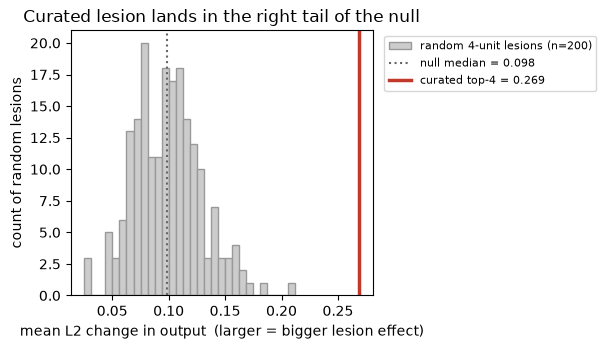

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.2, 3.6))
# the null distribution: effects of 200 random 4-unit lesions
ax.hist(null, bins=30, color='0.8', edgecolor='0.6', label='random 4-unit lesions (n=200)')
ax.axvline(med, ls=':', c='0.4', label=f'null median = {med:.3f}')
# where the curated top-4 lesion falls on the same axis (far right = bigger effect)
ax.axvline(curated_effect, c='#c0392b', lw=2.5, label=f'curated top-4 = {curated_effect:.3f}')
ax.set_xlabel('mean L2 change in output  (larger = bigger lesion effect)')
ax.set_ylabel('count of random lesions')
ax.set_title('Curated lesion lands in the right tail of the null')
# legend anchored just outside the axes so it never covers the bars or the tail line
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout(); plt.show()

## Exact restoration

`reset()` undoes every active perturbation. The restored output equals the baseline
bit-for-bit.

In [5]:
bs.reset()                                  # remove any lesion still in place
restored = net(x).detach().numpy()
# reset() detaches the hooks that were zeroing units, so the network returns to exactly
# its original behaviour -- not approximately, identically.
print('restored equals baseline exactly:', np.array_equal(restored, baseline))

restored equals baseline exactly: True


**Interpretation.** The grey band is the effect of lesioning 4 random units. The curated
top-4 falls above it, indicating that those units account for more of the output than
chance and that the lesion targets identifiable structure rather than an arbitrary set of
4 units. `reset()` then returns the network to its exact prior state.